# 7 - Person-Level Aggregation + Modeling

Each row is a person (scoped by conference) with behavior features aggregated across sessions/chunks.

Targets:
- `outcome_joined_team`
- `outcome_joined_funded_team`

In [1]:
from __future__ import annotations

import json
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold

BASE = Path('/Users/maxchalekson/Projects/gemini_data_analysis')
OUTPUTS_DIR = BASE / 'outputs'
OUTCOME_DIR = BASE / 'analysis_v1' / 'data'
V2_DATA_DIR = BASE / 'analysis_v2' / 'data'
V2_DATA_DIR.mkdir(parents=True, exist_ok=True)

GLOBAL_BY_CONF_PATH = BASE / 'finalized_matching_csvs' / 'global_participant_identity_by_conference.csv'
ALIAS_MAP_PATH = BASE / 'participant_alias_mapping.csv'

print('Using:')
print(' -', GLOBAL_BY_CONF_PATH)
print(' -', ALIAS_MAP_PATH)

Using:
 - /Users/maxchalekson/Projects/gemini_data_analysis/finalized_matching_csvs/global_participant_identity_by_conference.csv
 - /Users/maxchalekson/Projects/gemini_data_analysis/participant_alias_mapping.csv


In [2]:
def norm_name(text: object) -> str:
    s = '' if text is None else str(text)
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    s = s.lower().strip()
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


def safe_float(value: object, default: float = 0.0) -> float:
    if value is None:
        return default
    if isinstance(value, (int, float)):
        return float(value)
    text = str(value).strip()
    if not text:
        return default
    m = re.search(r'-?\d+(?:\.\d+)?', text)
    return float(m.group(0)) if m else default


alias_map = {}
if ALIAS_MAP_PATH.exists():
    alias_df = pd.read_csv(ALIAS_MAP_PATH)
    for _, row in alias_df.iterrows():
        a = norm_name(row.get('alias_name'))
        c = norm_name(row.get('canonical_name'))
        if a and c:
            alias_map[a] = c


def resolve_alias(name: str) -> str:
    cur = name
    seen = set()
    while cur in alias_map and cur not in seen:
        seen.add(cur)
        cur = alias_map[cur]
    return cur


by_conf_df = pd.read_csv(GLOBAL_BY_CONF_PATH).copy()
by_conf_df['conference'] = by_conf_df['conference'].astype(str).str.strip()
by_conf_df['normalized_name'] = by_conf_df['normalized_name'].astype(str).map(norm_name).map(resolve_alias)

person_lookup = {}
for _, row in by_conf_df.iterrows():
    person_lookup[(row['conference'], row['normalized_name'])] = row['global_person_id']

print('mappings:', len(person_lookup), '| unique people:', by_conf_df['global_person_id'].nunique())

mappings: 686 | unique people: 550


In [3]:
# Outcomes from truth files
outcome_records = []
for p in sorted(OUTCOME_DIR.glob('*/*_outcome.json')):
    conference = p.parent.name.strip()
    data = json.loads(p.read_text())
    if not isinstance(data, list):
        continue
    for team in data:
        funded = int(team.get('funded_status', 0))
        members = team.get('members', [])
        if not isinstance(members, list):
            continue
        for member in members:
            nm = resolve_alias(norm_name(member))
            pid = person_lookup.get((conference, nm))
            if pid:
                outcome_records.append({
                    'conference': conference,
                    'global_person_id': pid,
                    'outcome_joined_team': 1,
                    'outcome_joined_funded_team': funded,
                })

outcome_df = pd.DataFrame(outcome_records)
if outcome_df.empty:
    outcome_df = pd.DataFrame(columns=['conference', 'global_person_id', 'outcome_joined_team', 'outcome_joined_funded_team'])
else:
    outcome_df = outcome_df.groupby(['conference', 'global_person_id'], as_index=False).agg(
        outcome_joined_team=('outcome_joined_team', 'max'),
        outcome_joined_funded_team=('outcome_joined_funded_team', 'max'),
    )

# Features from output json files
rows = []
for conf_dir in sorted(OUTPUTS_DIR.glob('*')):
    if not conf_dir.is_dir():
        continue
    conference = conf_dir.name
    for out_dir in sorted(conf_dir.glob('output_*')):
        if not out_dir.is_dir():
            continue
        session_group = out_dir.name.replace('output_', '')
        for json_path in out_dir.rglob('*.json'):
            try:
                payload = json.loads(json_path.read_text())
            except Exception:
                continue
            if not isinstance(payload, dict):
                continue

            chunk_summary = payload.get('chunk_summary', {})
            dom_name = resolve_alias(norm_name(chunk_summary.get('dominant_speaker_name')))
            utterances = payload.get('utterance_annotations', [])
            if not isinstance(utterances, list):
                continue

            chunk_people = set()
            for utt in utterances:
                if not isinstance(utt, dict):
                    continue
                speaker = resolve_alias(norm_name(utt.get('speaker')))
                pid = person_lookup.get((conference, speaker))
                if not pid:
                    continue
                chunk_people.add(pid)

                codes = utt.get('codes') or []
                subcodes = []
                for c in codes:
                    if isinstance(c, dict):
                        sc = str(c.get('subcode', '')).strip().lower()
                        if sc:
                            subcodes.append(sc)

                rows.append({
                    'conference': conference,
                    'session_group': session_group,
                    'chunk_file': str(json_path.relative_to(BASE)),
                    'global_person_id': pid,
                    'utterance_count': 1,
                    'speaking_seconds': float(utt.get('speaking_duration_seconds', 0) or 0),
                    'dominant_speaker_chunks': int(bool(dom_name and speaker == dom_name)),
                    'hesitation_count': int(str(utt.get('hesitation_flag', '')).strip().lower() == 'yes'),
                    'backchannel_count': int(str(utt.get('audible_backchannel', '')).strip().lower() == 'yes'),
                    'n_build_subcodes': sum(1 for sc in subcodes if 'build' in sc),
                    'n_feedback_subcodes': sum(1 for sc in subcodes if 'feedback' in sc),
                    'n_question_subcodes': sum(1 for sc in subcodes if 'question' in sc),
                    'vocal_enthusiasm_sum': safe_float(utt.get('vocal_enthusiasm', 0), 0.0),
                })

            for pid in chunk_people:
                rows.append({
                    'conference': conference,
                    'session_group': session_group,
                    'chunk_file': str(json_path.relative_to(BASE)),
                    'global_person_id': pid,
                    'utterance_count': 0,
                    'speaking_seconds': 0.0,
                    'dominant_speaker_chunks': 0,
                    'hesitation_count': 0,
                    'backchannel_count': 0,
                    'n_build_subcodes': 0,
                    'n_feedback_subcodes': 0,
                    'n_question_subcodes': 0,
                    'vocal_enthusiasm_sum': 0.0,
                })

events_df = pd.DataFrame(rows)
agg_df = events_df.groupby(['conference', 'global_person_id'], as_index=False).agg(
    n_sessions_seen=('session_group', 'nunique'),
    n_chunks_seen=('chunk_file', 'nunique'),
    utterance_count=('utterance_count', 'sum'),
    speaking_seconds_total=('speaking_seconds', 'sum'),
    dominant_speaker_chunks=('dominant_speaker_chunks', 'sum'),
    hesitation_count=('hesitation_count', 'sum'),
    backchannel_count=('backchannel_count', 'sum'),
    n_build_subcodes=('n_build_subcodes', 'sum'),
    n_feedback_subcodes=('n_feedback_subcodes', 'sum'),
    n_question_subcodes=('n_question_subcodes', 'sum'),
    vocal_enthusiasm_sum=('vocal_enthusiasm_sum', 'sum'),
)

agg_df['speaking_seconds_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['speaking_seconds_total'] / agg_df['utterance_count'], 0.0)
agg_df['dominant_speaker_rate'] = np.where(agg_df['n_chunks_seen'] > 0, agg_df['dominant_speaker_chunks'] / agg_df['n_chunks_seen'], 0.0)
agg_df['build_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_build_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['feedback_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_feedback_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['question_per_utterance'] = np.where(agg_df['utterance_count'] > 0, agg_df['n_question_subcodes'] / agg_df['utterance_count'], 0.0)
agg_df['hesitation_rate'] = np.where(agg_df['utterance_count'] > 0, agg_df['hesitation_count'] / agg_df['utterance_count'], 0.0)
agg_df['backchannel_rate'] = np.where(agg_df['utterance_count'] > 0, agg_df['backchannel_count'] / agg_df['utterance_count'], 0.0)
agg_df['avg_vocal_enthusiasm'] = np.where(agg_df['utterance_count'] > 0, agg_df['vocal_enthusiasm_sum'] / agg_df['utterance_count'], 0.0)

person_df = agg_df.merge(outcome_df, on=['conference', 'global_person_id'], how='left')
person_df['outcome_joined_team'] = person_df['outcome_joined_team'].fillna(0).astype(int)
person_df['outcome_joined_funded_team'] = person_df['outcome_joined_funded_team'].fillna(0).astype(int)
name_df = by_conf_df[['conference', 'global_person_id', 'normalized_name']].drop_duplicates()
person_df = person_df.merge(name_df, on=['conference', 'global_person_id'], how='left')

person_df = person_df[['conference', 'global_person_id', 'normalized_name'] + [c for c in person_df.columns if c not in {'conference', 'global_person_id', 'normalized_name'}]]

print('person_df:', person_df.shape)
print('team rate:', round(person_df['outcome_joined_team'].mean(), 4))
print('funded rate:', round(person_df['outcome_joined_funded_team'].mean(), 4))
person_df.head()

person_df: (639, 24)
team rate: 0.4601
funded rate: 0.205


,conference,global_person_id,normalized_name,n_sessions_seen,n_chunks_seen,utterance_count,speaking_seconds_total,dominant_speaker_chunks,hesitation_count,backchannel_count,...,speaking_seconds_per_utterance,dominant_speaker_rate,build_per_utterance,feedback_per_utterance,question_per_utterance,hesitation_rate,backchannel_rate,avg_vocal_enthusiasm,outcome_joined_team,outcome_joined_funded_team
0,2020NES,person_0001,andrew feig,5,9,29,350.0,3,1,0,...,12.068966,0.333333,0.0,0.0,0.000000,0.034483,0.000000,2.034483,0,0
1,2020NES,person_0002,richard wiener,3,4,16,449.0,7,0,0,...,28.062500,1.750000,0.0,0.0,0.000000,0.000000,0.000000,2.000000,0,0
2,2020NES,person_0003,silvia ronco,1,1,1,6.0,0,0,0,...,6.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,3.000000,0,0
3,2020NES,person_0013,adam holewinski,3,21,48,1421.0,0,12,7,...,29.604167,0.000000,0.0,0.0,0.083333,0.250000,0.145833,2.000000,1,0
4,2020NES,person_0016,alissa park,2,16,108,2596.0,18,0,16,...,24.037037,1.125000,0.0,0.0,0.092593,0.000000,0.148148,2.175926,0,0


In [4]:
out_parquet = V2_DATA_DIR / 'person_features.parquet'
out_csv = V2_DATA_DIR / 'person_features.csv'
person_df.to_csv(out_csv, index=False)
print('Saved:')
print(' -', out_csv)

try:
    person_df.to_parquet(out_parquet, index=False)
    print(' -', out_parquet)
except Exception as exc:
    print(' - parquet skipped:', exc)

Saved:
 - /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_features.csv
 - parquet skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.


In [5]:
# Quick baseline: leave-one-conference-out logistic models
id_cols = {'conference', 'global_person_id', 'normalized_name'}
target_cols = {'outcome_joined_team', 'outcome_joined_funded_team'}
feature_cols = [c for c in person_df.columns if c not in id_cols | target_cols and pd.api.types.is_numeric_dtype(person_df[c])]

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced'))
])

def loco_eval(df, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        pipe.fit(tr[feature_cols], tr[target])
        p = pipe.predict_proba(te[feature_cols])[:, 1]
        y_true_all.extend(te[target].tolist())
        y_score_all.extend(p.tolist())
    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

summary = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    auc, auprc = loco_eval(person_df, target)
    summary.append({'target': target, 'auc_loco': auc, 'auprc_loco': auprc})

summary_df = pd.DataFrame(summary)
summary_path = V2_DATA_DIR / 'person_model_loco_summary.csv'
summary_df.to_csv(summary_path, index=False)
print('Saved:', summary_path)
summary_df

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_model_loco_summary.csv


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packag

,target,auc_loco,auprc_loco
0,outcome_joined_team,0.835690,0.758062
1,outcome_joined_funded_team,0.755319,0.373747


In [6]:
# Global-person view: one row per global_person_id across all conferences
sum_cols = [
    'n_sessions_seen', 'n_chunks_seen', 'utterance_count', 'speaking_seconds_total',
    'dominant_speaker_chunks', 'hesitation_count', 'backchannel_count',
    'n_build_subcodes', 'n_feedback_subcodes', 'n_question_subcodes', 'vocal_enthusiasm_sum'
]
sum_cols = [c for c in sum_cols if c in person_df.columns]

agg_spec = {c: 'sum' for c in sum_cols}
agg_spec['conference'] = 'nunique'
agg_spec['normalized_name'] = 'first'
agg_spec['outcome_joined_team'] = 'max'
agg_spec['outcome_joined_funded_team'] = 'max'

global_person_df = (
    person_df.sort_values(['global_person_id', 'conference'])
    .groupby('global_person_id', as_index=False)
    .agg(agg_spec)
    .rename(columns={'conference': 'n_conferences_seen'})
)

global_person_df['speaking_seconds_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['speaking_seconds_total'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['dominant_speaker_rate'] = np.where(
    global_person_df['n_chunks_seen'] > 0,
    global_person_df['dominant_speaker_chunks'] / global_person_df['n_chunks_seen'],
    0.0,
)
global_person_df['build_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_build_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['feedback_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_feedback_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['question_per_utterance'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['n_question_subcodes'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['hesitation_rate'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['hesitation_count'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['backchannel_rate'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['backchannel_count'] / global_person_df['utterance_count'],
    0.0,
)
global_person_df['avg_vocal_enthusiasm'] = np.where(
    global_person_df['utterance_count'] > 0,
    global_person_df['vocal_enthusiasm_sum'] / global_person_df['utterance_count'],
    0.0,
)

global_csv = V2_DATA_DIR / 'person_features_global.csv'
global_parquet = V2_DATA_DIR / 'person_features_global.parquet'
global_person_df.to_csv(global_csv, index=False)
print('Saved:', global_csv)
try:
    global_person_df.to_parquet(global_parquet, index=False)
    print('Saved:', global_parquet)
except Exception as exc:
    print('Parquet skipped:', exc)

global_person_df.head()

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_features_global.csv
Parquet skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.


,global_person_id,n_sessions_seen,n_chunks_seen,utterance_count,speaking_seconds_total,dominant_speaker_chunks,hesitation_count,backchannel_count,n_build_subcodes,n_feedback_subcodes,...,outcome_joined_team,outcome_joined_funded_team,speaking_seconds_per_utterance,dominant_speaker_rate,build_per_utterance,feedback_per_utterance,question_per_utterance,hesitation_rate,backchannel_rate,avg_vocal_enthusiasm
0,person_0001,52,73,192,2513.0,6,2,5,2,0,...,0,0,13.088542,0.082192,0.010417,0.0,0.026042,0.010417,0.026042,2.036458
1,person_0002,47,81,203,2998.0,31,1,2,0,0,...,0,0,14.768473,0.382716,0.000000,0.0,0.019704,0.004926,0.009852,1.995074
2,person_0003,29,34,96,818.0,0,0,3,0,0,...,0,0,8.520833,0.000000,0.000000,0.0,0.104167,0.000000,0.031250,2.041667
3,person_0004,12,16,18,246.0,0,0,0,0,0,...,0,0,13.666667,0.000000,0.000000,0.0,0.111111,0.000000,0.000000,1.722222
4,person_0005,4,4,4,39.0,0,0,0,0,0,...,0,0,9.750000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,2.250000


In [7]:
# Quick model for global-person table (stratified CV)
global_model_df = global_person_df.copy()
global_id_cols = {'global_person_id', 'normalized_name'}
global_target_cols = {'outcome_joined_team', 'outcome_joined_funded_team'}
global_feature_cols = [
    c for c in global_model_df.columns
    if c not in global_id_cols | global_target_cols and pd.api.types.is_numeric_dtype(global_model_df[c])
]

global_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced')),
])

def stratified_cv_eval(df, feature_cols, target, seed=42):
    y = df[target].astype(int).values
    X = df[feature_cols]
    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        return np.nan, np.nan
    n_splits = int(min(5, class_counts.min()))
    if n_splits < 2:
        return np.nan, np.nan

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y_true_all, y_score_all = [], []
    for tr_idx, te_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        global_pipe.fit(X_tr, y_tr)
        p = global_pipe.predict_proba(X_te)[:, 1]
        y_true_all.extend(y_te.tolist())
        y_score_all.extend(p.tolist())

    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

global_summary_rows = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    auc, auprc = stratified_cv_eval(global_model_df, global_feature_cols, target)
    global_summary_rows.append({'target': target, 'auc_stratified_cv': auc, 'auprc_stratified_cv': auprc})

global_summary_df = pd.DataFrame(global_summary_rows)
global_summary_path = V2_DATA_DIR / 'person_model_global_cv_summary.csv'
global_summary_df.to_csv(global_summary_path, index=False)
print('Saved:', global_summary_path)
global_summary_df

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_model_global_cv_summary.csv


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packag

,target,auc_stratified_cv,auprc_stratified_cv
0,outcome_joined_team,0.859449,0.809607
1,outcome_joined_funded_team,0.791563,0.477636


In [8]:
# Class balance for person-within-conference outcomes
balance_rows = []
for target in ['outcome_joined_team', 'outcome_joined_funded_team']:
    y = person_df[target].astype(int)
    n = len(y)
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    balance_rows.append({
        'target': target,
        'n_rows': n,
        'n_positive': n_pos,
        'n_negative': n_neg,
        'positive_rate': (n_pos / n) if n else np.nan,
        'negative_rate': (n_neg / n) if n else np.nan,
    })

class_balance_df = pd.DataFrame(balance_rows)
class_balance_path = V2_DATA_DIR / 'person_model_class_balance.csv'
class_balance_df.to_csv(class_balance_path, index=False)
print('Saved:', class_balance_path)
class_balance_df

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_model_class_balance.csv


,target,n_rows,n_positive,n_negative,positive_rate,negative_rate
0,outcome_joined_team,639,294,345,0.460094,0.539906
1,outcome_joined_funded_team,639,131,508,0.205008,0.794992


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packag

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/figures/person_model_roc_curves.png


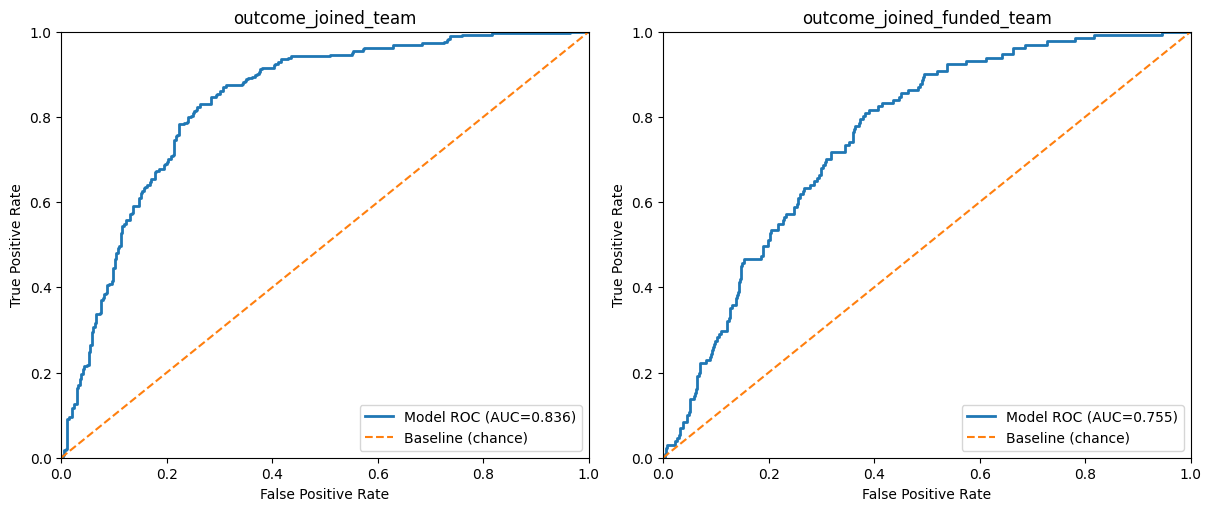

In [9]:
# ROC curves with baseline diagonal (conference-held-out predictions)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def loco_eval_scores(df, features, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        pipe.fit(tr[features], tr[target])
        p = pipe.predict_proba(te[features])[:, 1]
        y_true_all.extend(te[target].astype(int).tolist())
        y_score_all.extend(p.tolist())
    return np.array(y_true_all), np.array(y_score_all)

targets = ['outcome_joined_team', 'outcome_joined_funded_team']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, target in zip(axes, targets):
    y_true, y_score = loco_eval_scores(person_df, feature_cols, target)
    if len(np.unique(y_true)) < 2:
        ax.text(0.5, 0.5, f'Insufficient classes for {target}', ha='center', va='center')
        ax.set_title(target)
        continue

    auc_val = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, label=f'Model ROC (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], linestyle='--', lw=1.5, label='Baseline (chance)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(target)
    ax.legend(loc='lower right')

roc_fig_path = BASE / 'analysis_v2' / 'figures' / 'person_model_roc_curves.png'
roc_fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(roc_fig_path, dpi=150, bbox_inches='tight')
print('Saved:', roc_fig_path)
plt.show()

In [10]:
# Build detailed subcode features (person-within-conference)
subcode_rows = []
for conf_dir in sorted(OUTPUTS_DIR.glob('*')):
    if not conf_dir.is_dir():
        continue
    conference = conf_dir.name
    for out_dir in sorted(conf_dir.glob('output_*')):
        if not out_dir.is_dir():
            continue
        for json_path in out_dir.rglob('*.json'):
            try:
                payload = json.loads(json_path.read_text())
            except Exception:
                continue
            if not isinstance(payload, dict):
                continue
            utterances = payload.get('utterance_annotations', [])
            if not isinstance(utterances, list):
                continue

            for utt in utterances:
                if not isinstance(utt, dict):
                    continue
                speaker = resolve_alias(norm_name(utt.get('speaker')))
                pid = person_lookup.get((conference, speaker))
                if not pid:
                    continue

                for c in (utt.get('codes') or []):
                    if not isinstance(c, dict):
                        continue
                    sc = str(c.get('subcode', '')).strip().lower()
                    if not sc:
                        continue
                    sc_norm = re.sub(r'[^a-z0-9]+', '_', sc).strip('_')
                    if not sc_norm:
                        continue
                    subcode_rows.append({
                        'conference': conference,
                        'global_person_id': pid,
                        'subcode_feature': f'subcode__{sc_norm}',
                        'count': 1,
                    })

if subcode_rows:
    subcode_df = pd.DataFrame(subcode_rows)
    subcode_pivot = (
        subcode_df
        .groupby(['conference', 'global_person_id', 'subcode_feature'], as_index=False)['count'].sum()
        .pivot_table(index=['conference', 'global_person_id'], columns='subcode_feature', values='count', fill_value=0)
        .reset_index()
    )
    subcode_pivot.columns.name = None
else:
    subcode_pivot = pd.DataFrame(columns=['conference', 'global_person_id'])

person_df_detailed = person_df.merge(subcode_pivot, on=['conference', 'global_person_id'], how='left')
subcode_cols = [c for c in person_df_detailed.columns if c.startswith('subcode__')]
if subcode_cols:
    person_df_detailed[subcode_cols] = person_df_detailed[subcode_cols].fillna(0)

# requested naming
person_df_detailed['n_sessions_attended'] = person_df_detailed['n_sessions_seen']

detailed_path = V2_DATA_DIR / 'person_features_detailed_subcodes.csv'
person_df_detailed.to_csv(detailed_path, index=False)
print('Saved:', detailed_path)
print('Detailed subcode feature count:', len(subcode_cols))
person_df_detailed[['conference', 'global_person_id', 'normalized_name', 'n_sessions_attended'] + subcode_cols[:5]].head()

Saved: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person_features_detailed_subcodes.csv
Detailed subcode feature count: 70


,conference,global_person_id,normalized_name,n_sessions_attended,subcode__ambiguous,subcode__asks_clarifying_question,subcode__asks_factual_question,subcode__asks_for_elaboration,subcode__asks_for_opinion
0,2020NES,person_0001,andrew feig,5,0.0,0.0,0.0,0.0,1.0
1,2020NES,person_0002,richard wiener,3,0.0,0.0,0.0,0.0,0.0
2,2020NES,person_0003,silvia ronco,1,0.0,0.0,0.0,0.0,0.0
3,2020NES,person_0013,adam holewinski,3,14.0,3.0,0.0,0.0,2.0
4,2020NES,person_0016,alissa park,2,22.0,3.0,5.0,0.0,1.0


In [11]:
# Controls-only vs controls+single-subcode (LOCO) results
controls = [c for c in ['n_sessions_attended', 'speaking_seconds_total'] if c in person_df_detailed.columns]
targets = ['outcome_joined_team', 'outcome_joined_funded_team']
subcode_cols = [c for c in person_df_detailed.columns if c.startswith('subcode__')]

# keep only sufficiently present subcodes
min_total_count = 10
subcode_cols = [c for c in subcode_cols if person_df_detailed[c].sum() >= min_total_count]

pipe_sub = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced')),
])

def loco_eval_feats(df, feature_list, target):
    y_true_all, y_score_all = [], []
    for holdout in sorted(df['conference'].unique()):
        tr = df[df['conference'] != holdout]
        te = df[df['conference'] == holdout]
        if tr.empty or te.empty:
            continue
        if tr[target].nunique() < 2:
            continue
        X_tr = tr[feature_list]
        X_te = te[feature_list]
        y_tr = tr[target].astype(int)
        y_te = te[target].astype(int)
        pipe_sub.fit(X_tr, y_tr)
        p = pipe_sub.predict_proba(X_te)[:, 1]
        y_true_all.extend(y_te.tolist())
        y_score_all.extend(p.tolist())
    if len(set(y_true_all)) < 2:
        return np.nan, np.nan
    return roc_auc_score(y_true_all, y_score_all), average_precision_score(y_true_all, y_score_all)

rows = []
for target in targets:
    base_auc, base_auprc = loco_eval_feats(person_df_detailed, controls, target)
    rows.append({
        'target': target,
        'feature_type': 'controls_only',
        'feature_name': '__controls__',
        'auc_loco': base_auc,
        'auprc_loco': base_auprc,
        'delta_auc_vs_controls': 0.0,
        'delta_auprc_vs_controls': 0.0,
    })

    for sc in subcode_cols:
        feats = controls + [sc]
        auc, auprc = loco_eval_feats(person_df_detailed, feats, target)
        rows.append({
            'target': target,
            'feature_type': 'single_subcode_plus_controls',
            'feature_name': sc,
            'auc_loco': auc,
            'auprc_loco': auprc,
            'delta_auc_vs_controls': auc - base_auc if pd.notna(auc) and pd.notna(base_auc) else np.nan,
            'delta_auprc_vs_controls': auprc - base_auprc if pd.notna(auprc) and pd.notna(base_auprc) else np.nan,
        })

detailed_results_df = pd.DataFrame(rows)
detailed_results_path = V2_DATA_DIR / 'person_model_detailed_subcode_results.csv'
detailed_results_df.to_csv(detailed_results_path, index=False)
print('Saved:', detailed_results_path)

for target in targets:
    print(f'\\nTop subcodes by delta AUC for {target}:')
    display(
        detailed_results_df[
            (detailed_results_df['target'] == target) &
            (detailed_results_df['feature_type'] == 'single_subcode_plus_controls')
        ]
        .sort_values('delta_auc_vs_controls', ascending=False)
        .head(10)
    )

detailed_results_df.head()

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

...

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarn

,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
34,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_process,0.846347,0.770605,0.152913,0.199627
27,outcome_joined_team,single_subcode_plus_controls,subcode__invites_contribution,0.829991,0.748862,0.136557,0.177885
15,outcome_joined_team,single_subcode_plus_controls,subcode__encourages_participation,0.766746,0.668753,0.073312,0.097776
18,outcome_joined_team,single_subcode_plus_controls,subcode__expresses_appreciation,0.758109,0.664727,0.064675,0.093749
20,outcome_joined_team,single_subcode_plus_controls,subcode__extends_existing_idea,0.748812,0.665187,0.055378,0.094209
26,outcome_joined_team,single_subcode_plus_controls,subcode__individual_framing,0.748053,0.636782,0.054619,0.065805
38,outcome_joined_team,single_subcode_plus_controls,subcode__redirects_speaker,0.741063,0.631687,0.047629,0.060710
32,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_new_idea,0.740373,0.636829,0.046939,0.065852
8,outcome_joined_team,single_subcode_plus_controls,subcode__calls_for_decision,0.738430,0.614859,0.044997,0.043882
33,outcome_joined_team,single_subcode_plus_controls,subcode__proposes_next_step,0.737425,0.621759,0.043991,0.050782


\nTop subcodes by delta AUC for outcome_joined_funded_team:


,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
94,outcome_joined_funded_team,single_subcode_plus_controls,subcode__proposes_process,0.786440,0.402623,0.103189,0.106700
87,outcome_joined_funded_team,single_subcode_plus_controls,subcode__invites_contribution,0.773216,0.388875,0.089965,0.092952
75,outcome_joined_funded_team,single_subcode_plus_controls,subcode__encourages_participation,0.741284,0.361698,0.058033,0.065775
78,outcome_joined_funded_team,single_subcode_plus_controls,subcode__expresses_appreciation,0.729188,0.341236,0.045937,0.045313
93,outcome_joined_funded_team,single_subcode_plus_controls,subcode__proposes_next_step,0.723027,0.333472,0.039776,0.037549
86,outcome_joined_funded_team,single_subcode_plus_controls,subcode__individual_framing,0.722291,0.368589,0.039039,0.072666
80,outcome_joined_funded_team,single_subcode_plus_controls,subcode__extends_existing_idea,0.713049,0.362004,0.029798,0.066081
108,outcome_joined_funded_team,single_subcode_plus_controls,subcode__shares_domain_knowledge,0.712328,0.348255,0.029077,0.052332
113,outcome_joined_funded_team,single_subcode_plus_controls,subcode__summarizes_for_group,0.710540,0.319566,0.027289,0.023643
115,outcome_joined_funded_team,single_subcode_plus_controls,subcode__synthesizes_contributions,0.705866,0.316784,0.022615,0.020862


,target,feature_type,feature_name,auc_loco,auprc_loco,delta_auc_vs_controls,delta_auprc_vs_controls
0,outcome_joined_team,controls_only,__controls__,0.693434,0.570977,0.000000,0.000000
1,outcome_joined_team,single_subcode_plus_controls,subcode__ambiguous,0.699527,0.580682,0.006093,0.009704
2,outcome_joined_team,single_subcode_plus_controls,subcode__asks_clarifying_question,0.691176,0.568277,-0.002258,-0.002700
3,outcome_joined_team,single_subcode_plus_controls,subcode__asks_factual_question,0.690348,0.571296,-0.003086,0.000319
4,outcome_joined_team,single_subcode_plus_controls,subcode__asks_for_elaboration,0.701499,0.585674,0.008065,0.014697


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packag

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/miniconda3/lib/python3.13/site-packag

Saved summary: /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/data/person-aggregation-features/person_model_visualization_summary.csv
                    target  n_rows  feature_count  accuracy_loco_pooled  f1_loco_pooled  auc_loco_pooled  auprc_loco_pooled                                                                                                                                         behavior_figure_path                                                                                                                                     model_figure_path                                                                                                                                         coef_table_path
       outcome_joined_team     639             16              0.784038        0.762069         0.858109           0.786982        /Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_behavior_exploration_outcome_joi

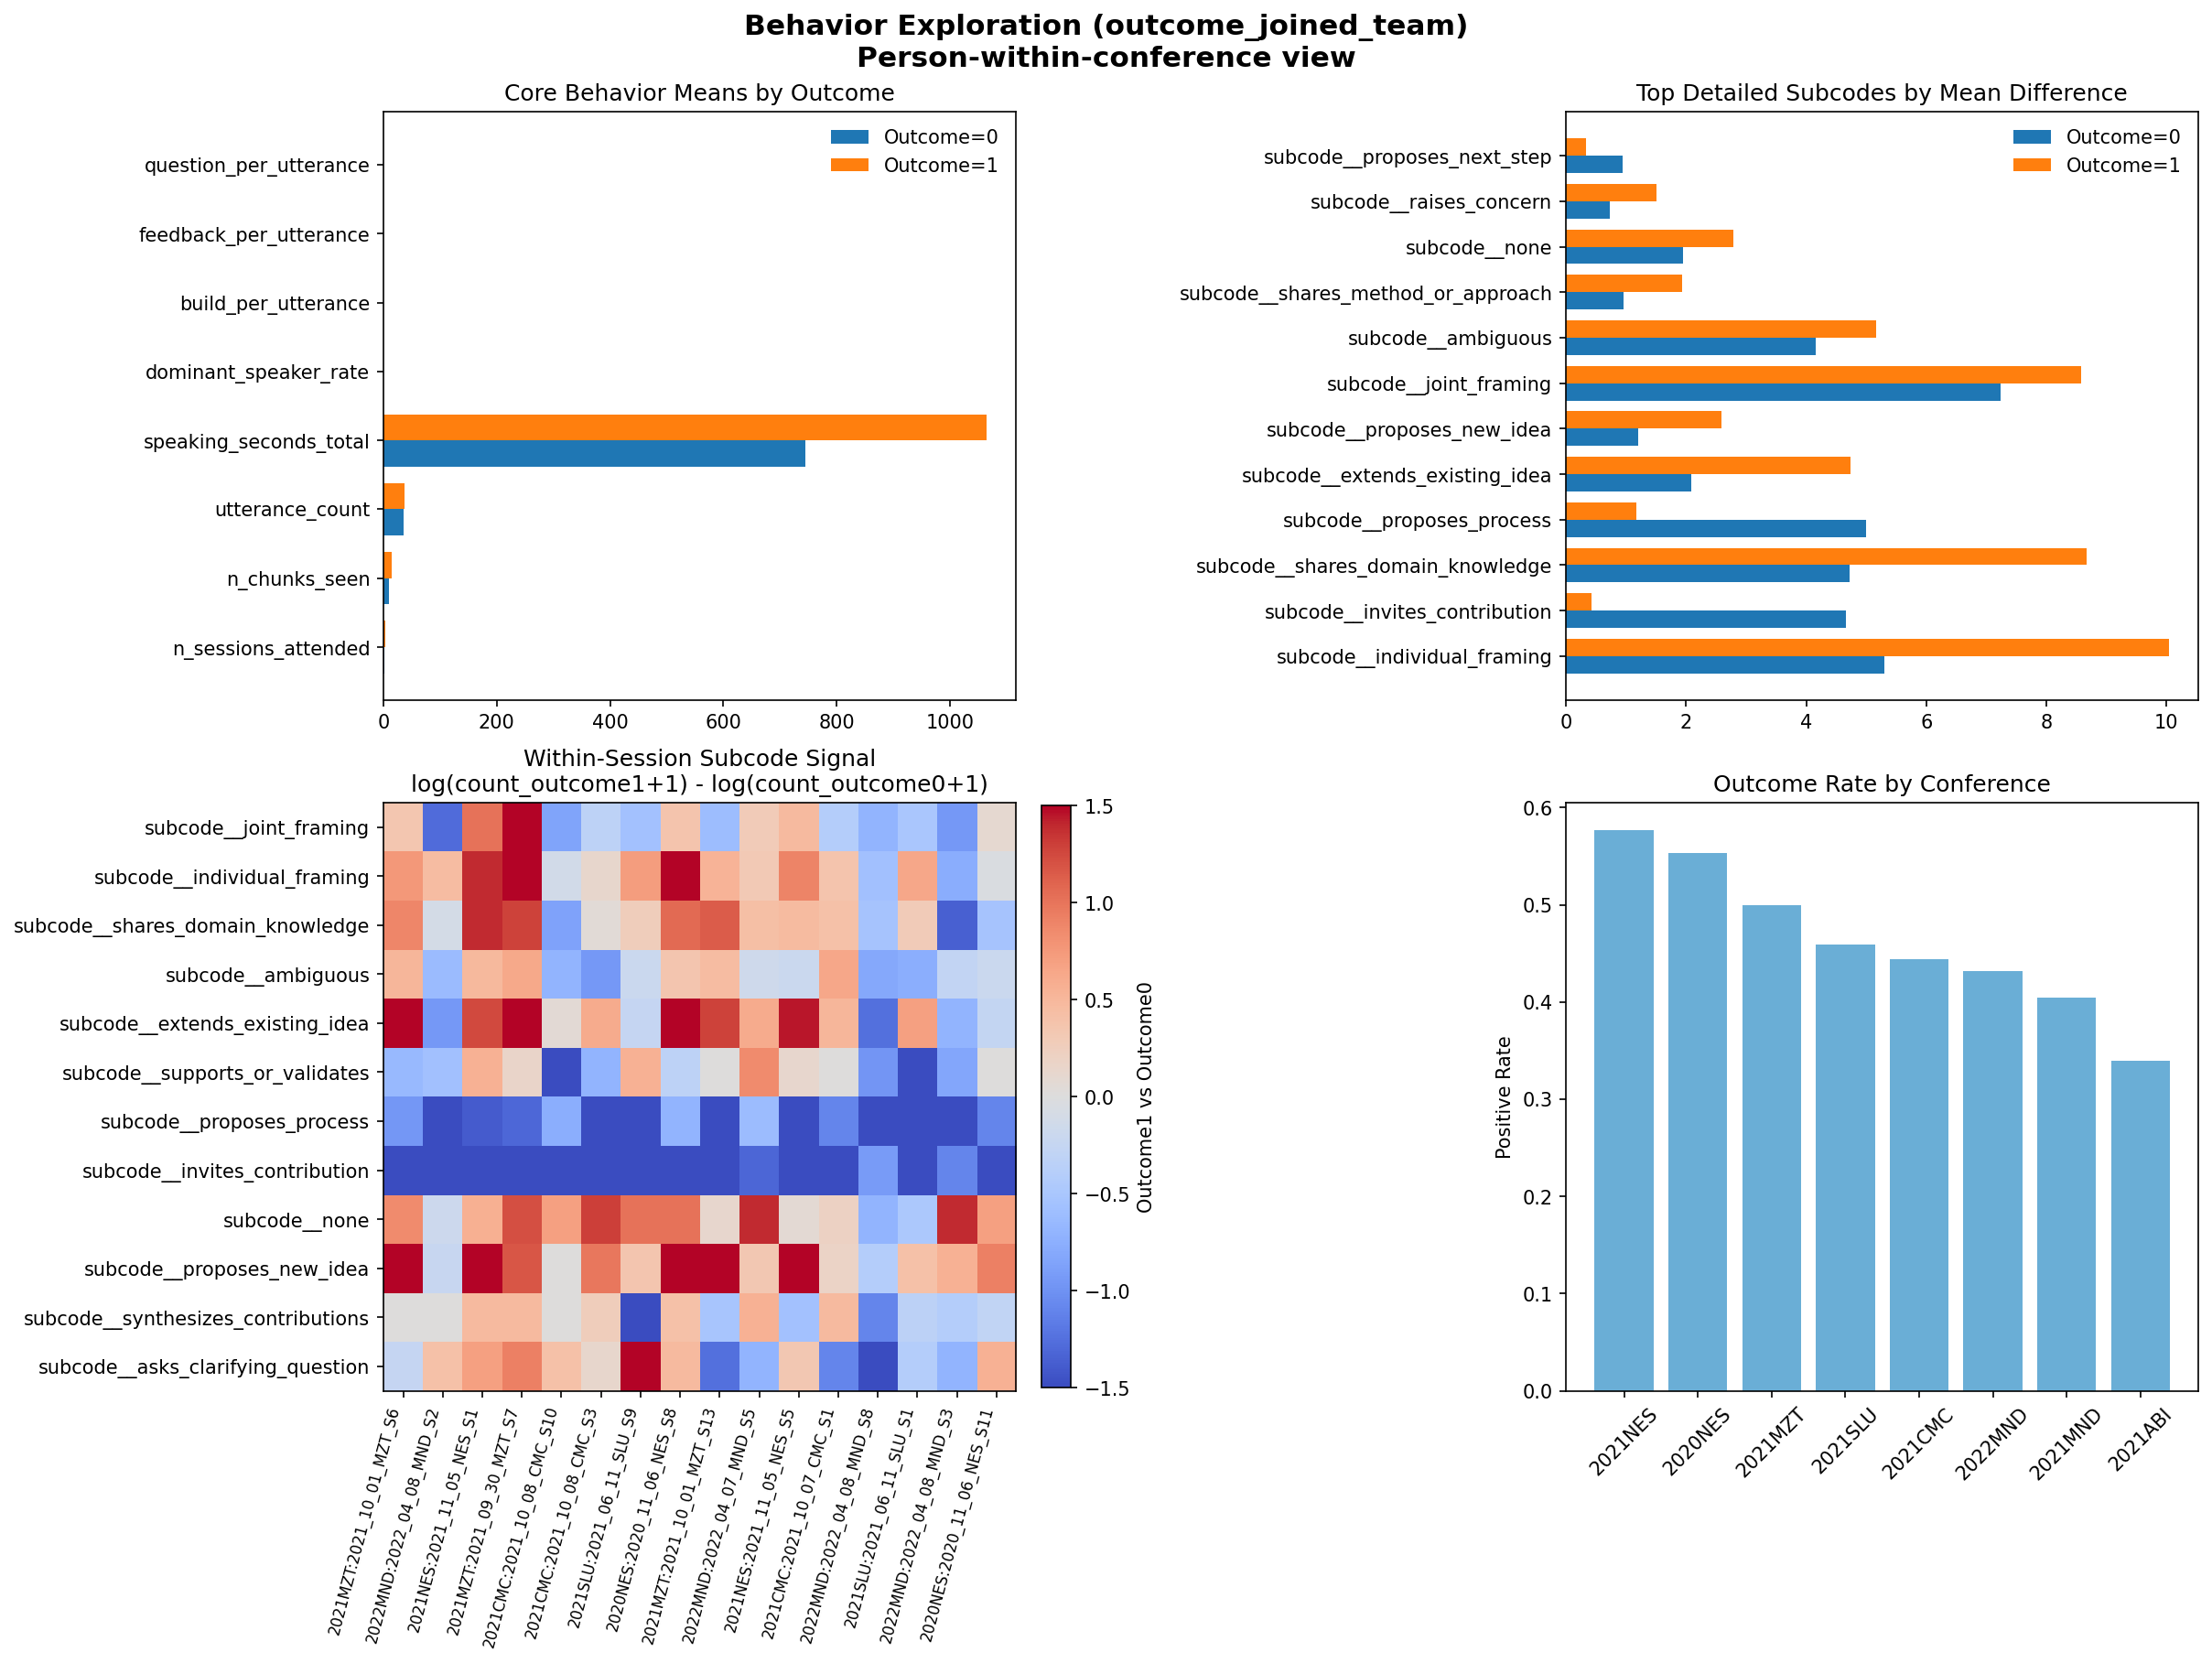

/Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_behavior_exploration_outcome_joined_funded_team.png


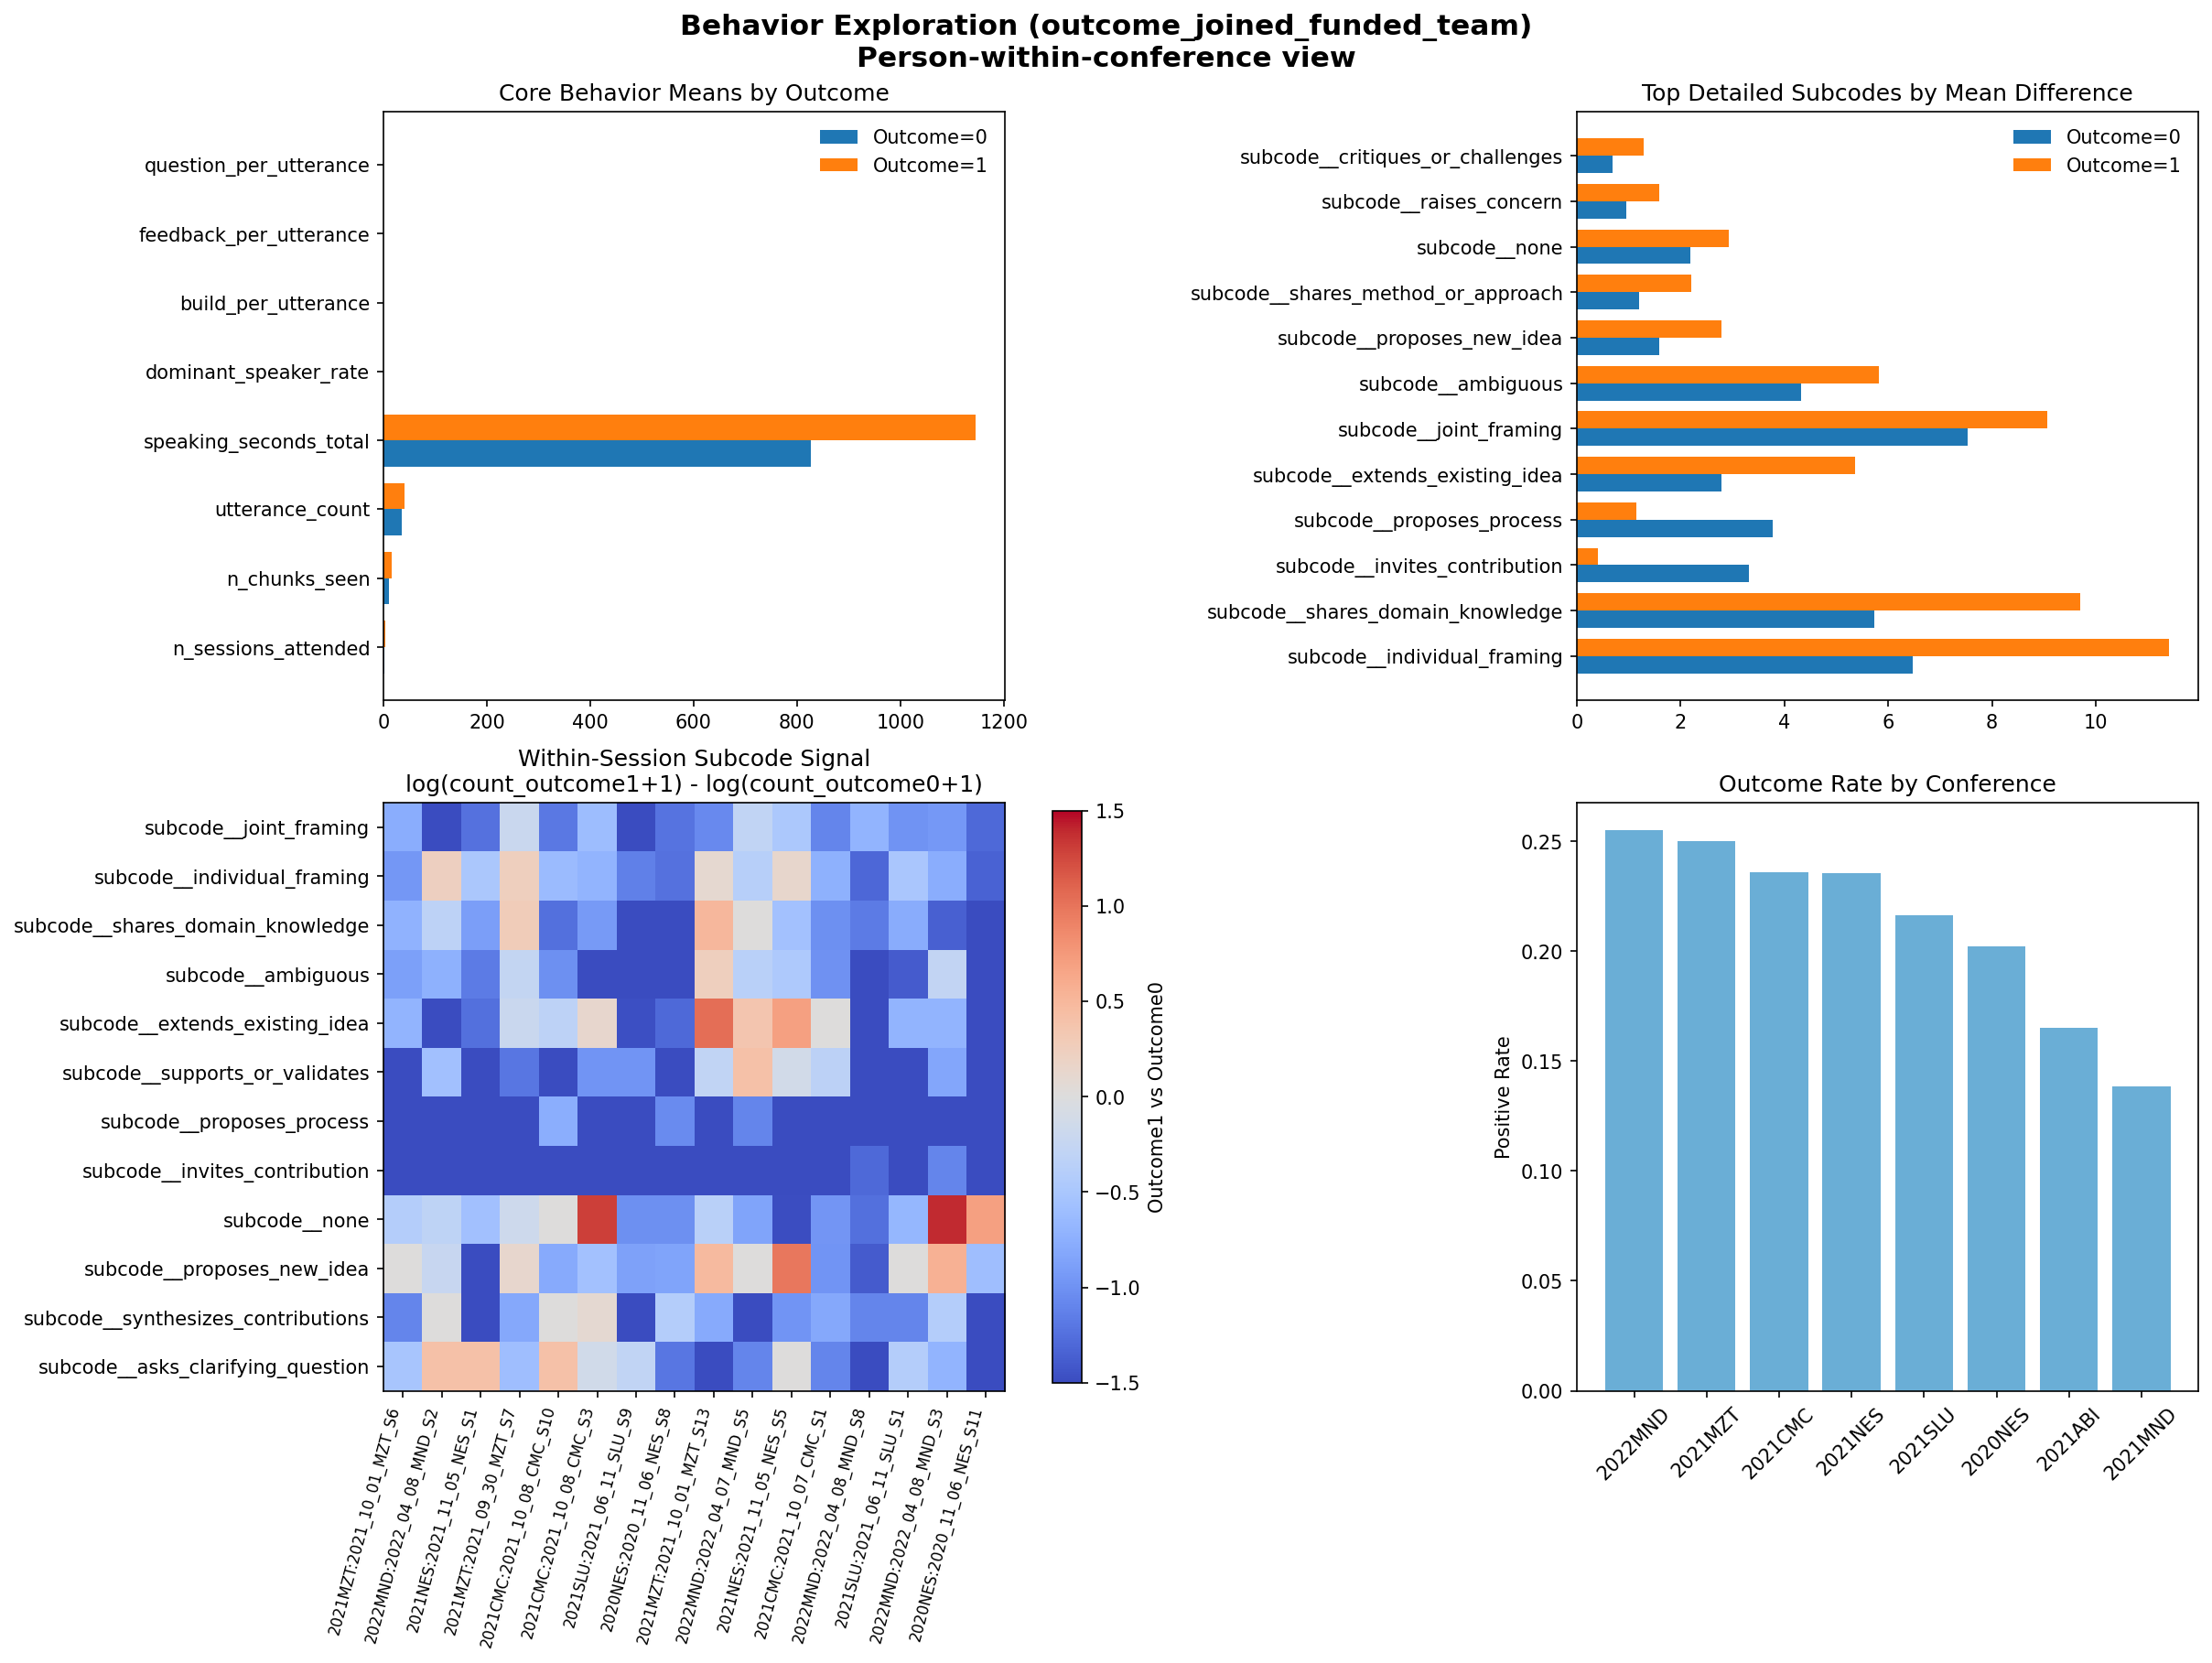

/Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_model_results_outcome_joined_team.png


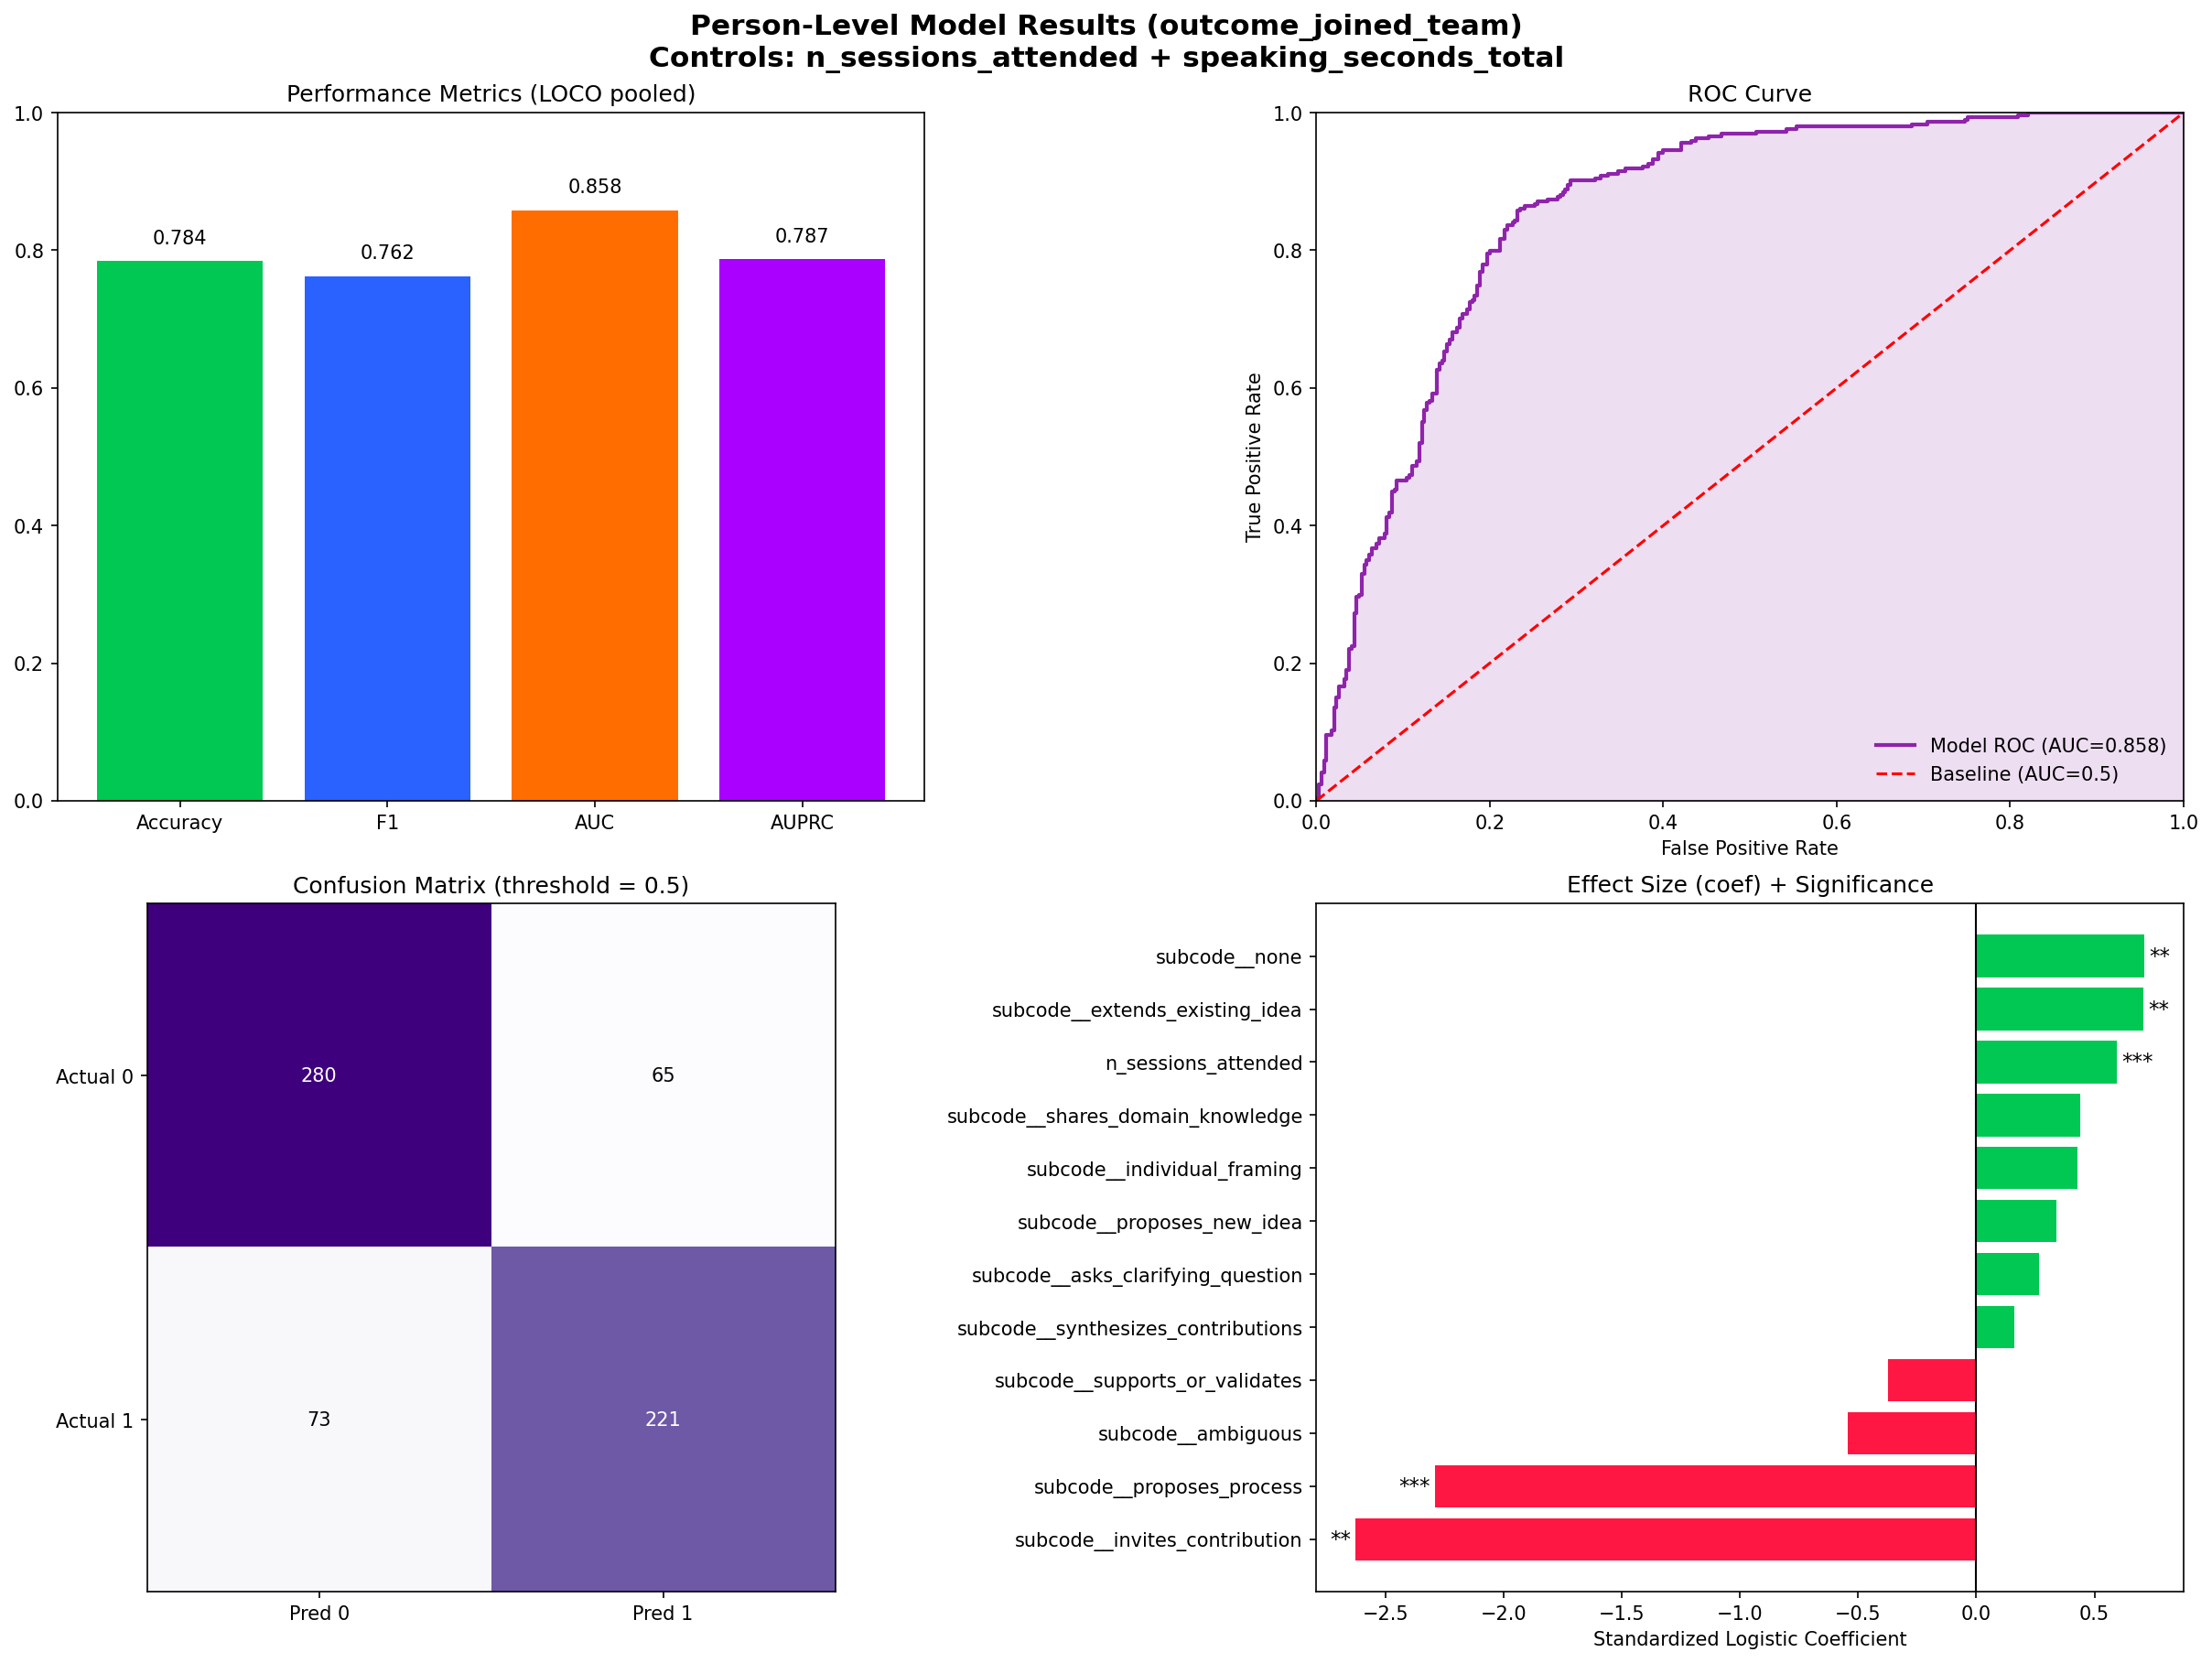

/Users/maxchalekson/Projects/gemini_data_analysis/analysis_v2/figures/person-aggregation-features/person_model_results_outcome_joined_funded_team.png


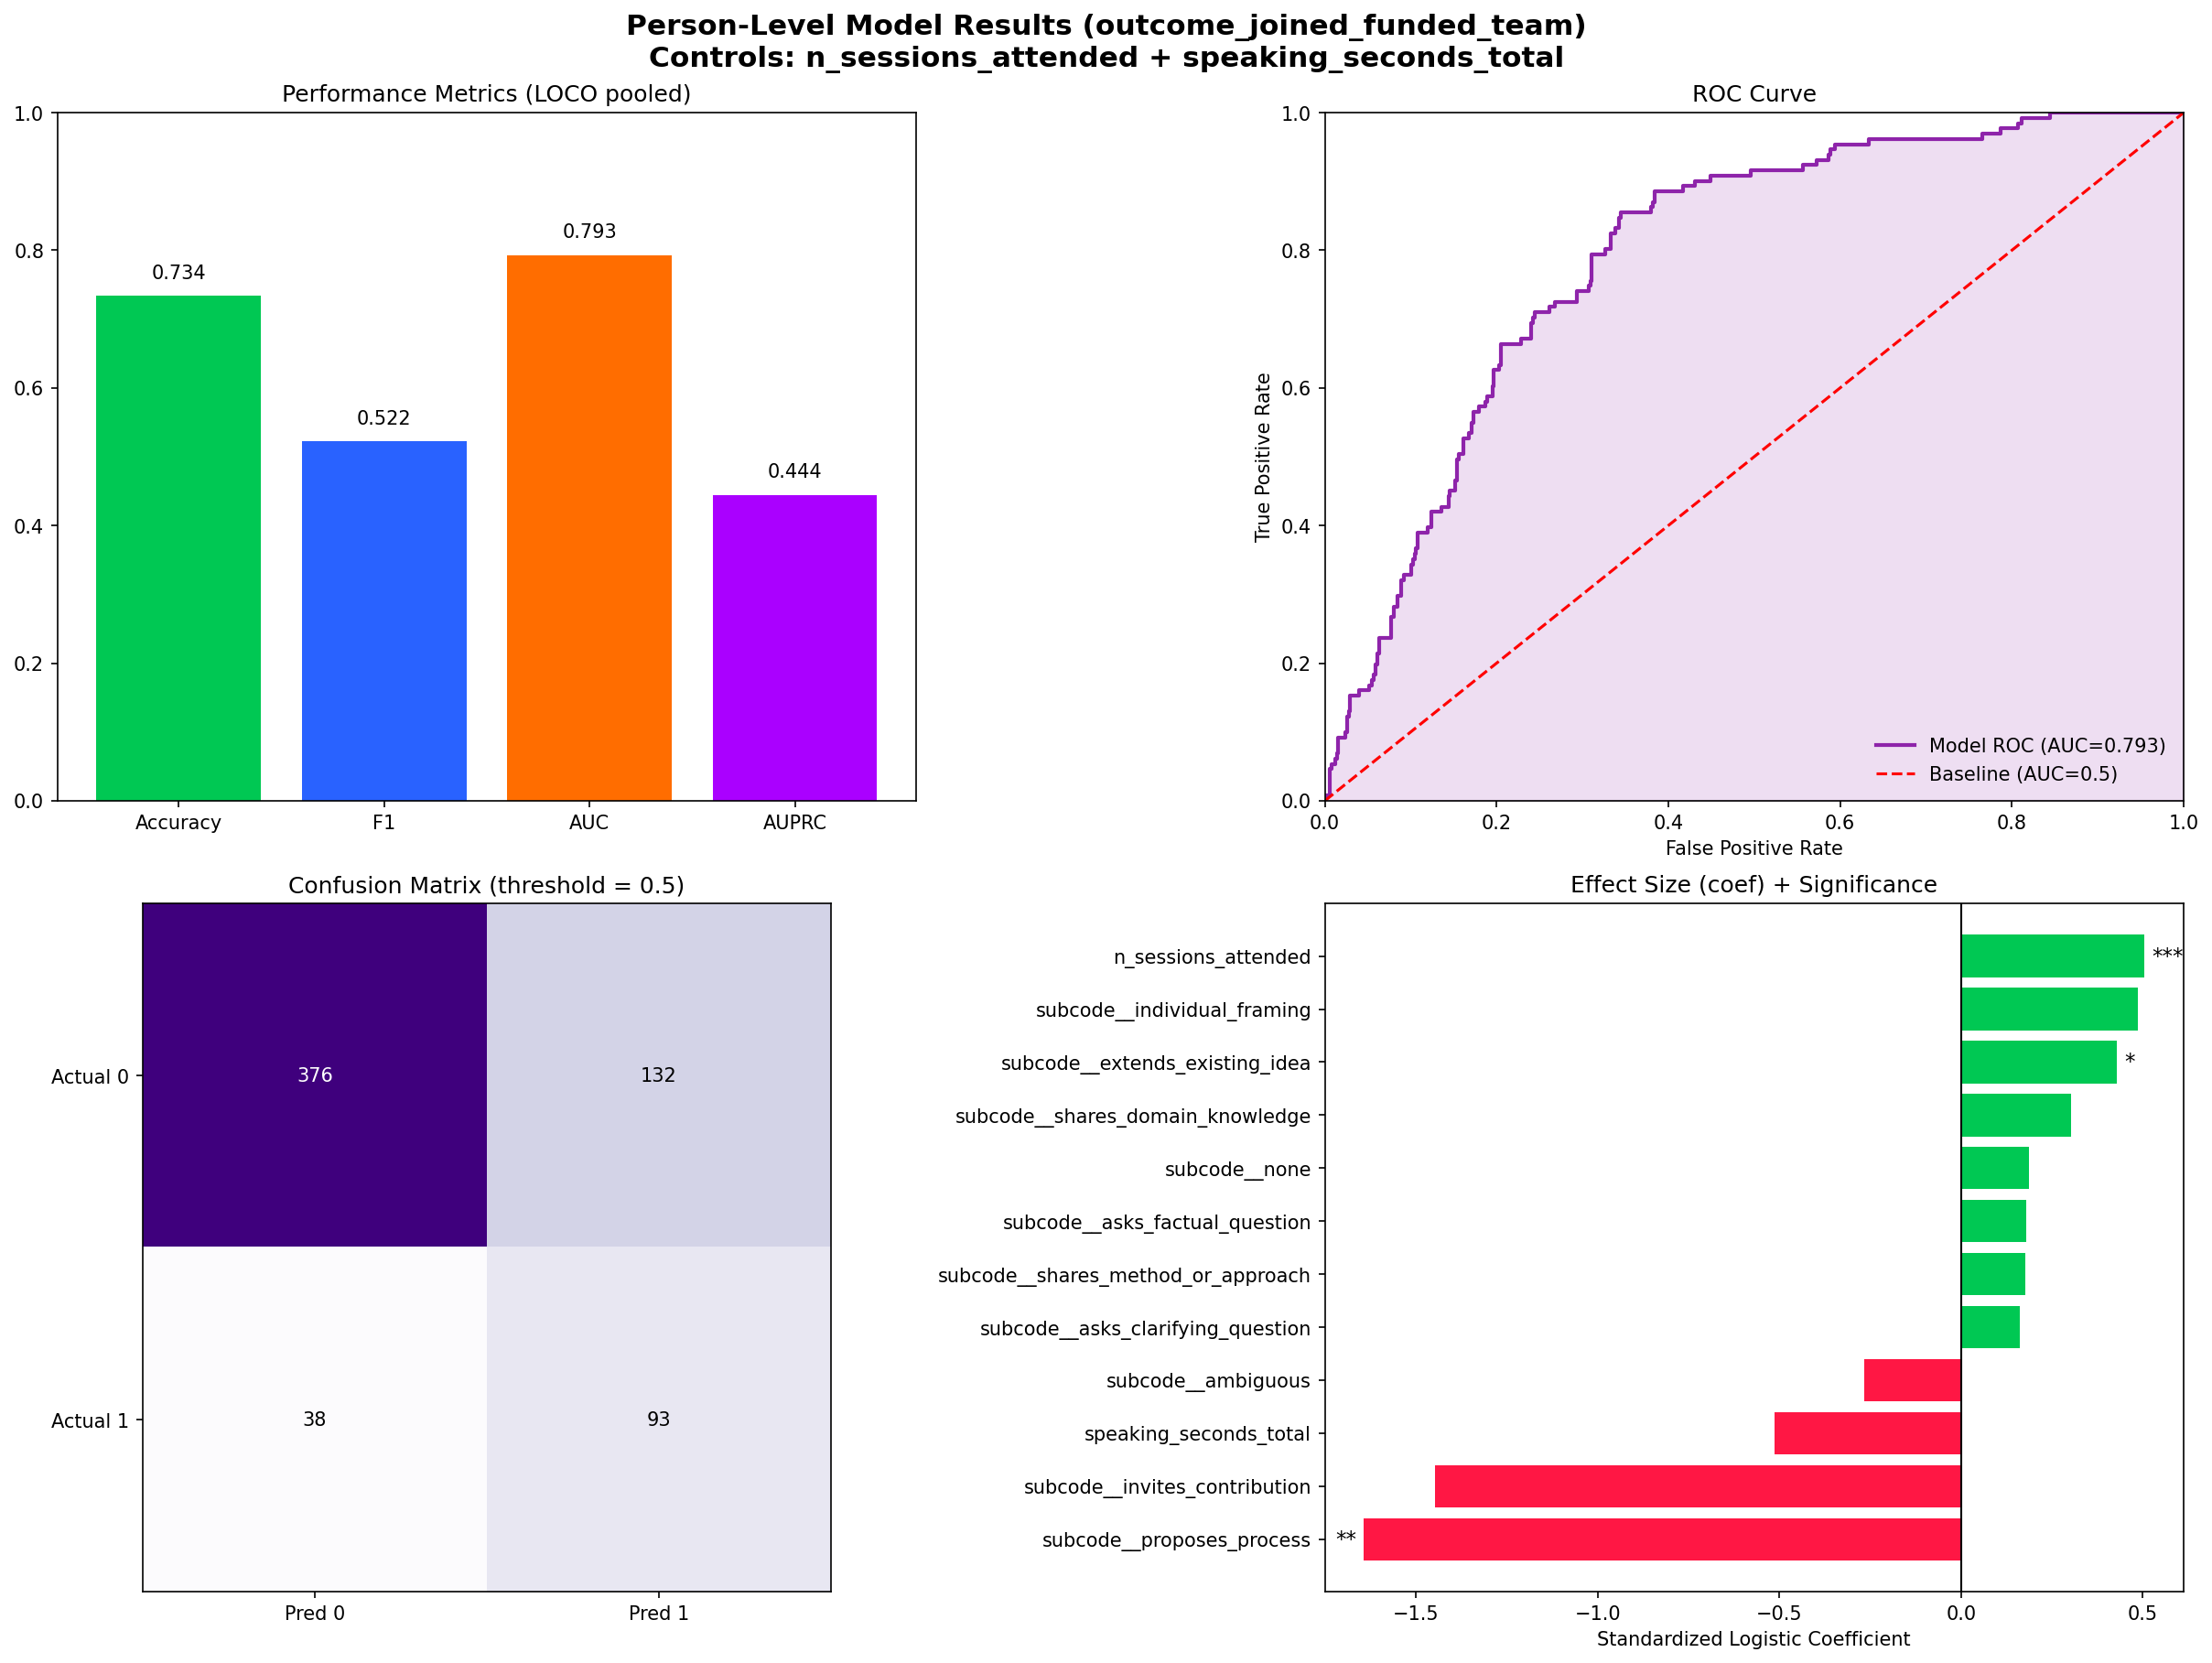

In [12]:
# Regenerate and display publication-style figures (overwrites same filenames)
import subprocess
from IPython.display import Image, display

SCRIPT_PATH = BASE / 'analysis_v2' / 'src' / 'person_visualizations.py'
subprocess.run(['python3', str(SCRIPT_PATH)], check=True)

FIG_DIR = BASE / 'analysis_v2' / 'figures' / 'person-aggregation-features'
for name in [
    'person_behavior_exploration_outcome_joined_team.png',
    'person_behavior_exploration_outcome_joined_funded_team.png',
    'person_model_results_outcome_joined_team.png',
    'person_model_results_outcome_joined_funded_team.png',
]:
    p = FIG_DIR / name
    print(p)
    display(Image(filename=str(p)))
